# Spatial Representations, Transformations, and Interpolation

This notebook introduces the main Cartesian-space tools in RobotBlockSet. Its purpose is to show how spatial variables are represented, how transformations between different representations are performed, and how Cartesian positions and orientations can be interpolated.


## What this notebook covers

The examples below demonstrate the core operations needed to work in Cartesian space: creating and converting pose representations, applying spatial transformations, using utility functions for spatial reasoning, and interpolating positions, orientations, and complete poses along a path or trajectory.

Use this notebook as a practical reference when you need to work with analytical pose representations, frame transformations, or Cartesian-space motion generation.


# Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from robotblockset.transformations import *
from robotblockset.tools import dist2lines
from robotblockset.trajectories import xinterp, slerp

from robotblockset.graphics import plotcpos_ori, plotucs
from robotblockset.trajectories import xarcinterp

np.set_printoptions(precision=4, suppress=True)

# Spatial functions and variables

To work with translation and rotation (position and orientation), RBS Toolbox provides:

- functions to create vectors and matrices representing the poses, positions and orientations in 3D space,
- functions for transformations between different representations,

- utility functions, 
- path and trajectory generation functions, and
- interpolation functions, and
- approximation functions.

### Representation of spatial variables

The position and orientation of an object can be described using different representations. In RBS Toolbox we use following representations:

| Representation | Single           | Multiple         | Comment                             |
| -------------- | ---------------- | ---------------- | ----------------------------------- |
| pose           | 4 x 4 matrix     | n x 4 x 4 array  | homogenous matrix                   |
| **pose**       | 1 x 7 vector     | n x 7 array      | **[position, quaternion]**         |
| position       | 3 x 1 vector     | n x 3 array      | position vector                     |
| orientation    | 3 x 3 matrix     | n x 3 x 3 array  | rotation matrix                     |
| orientation    | 1 x 4 vector     | n x 4 array      | unit quaternion elements            |
| orientation    | 1 x 3 vector     | n x 3 array      | Euler angles RPY (`Rz`* `Ry`* `Rx`) |

The vectors and matrices ar numpy arrays.



> ⚠️ **Note:** In RBS, the default form is "pose". So, most RBS functions related to spatial variables return by default position and orientation in form **pose = [position, quaternion]**. The output form can be changed using the argument `out` (For more info see the description of output forms of function `map_pose` later in the tutorial).

> ℹ️ **Note:**  Functions which arguments are spatial variables, the internally convert variable to numpy array. So, the variables can be defined also as lists.


# Translations and rotations

All rigid body movements are rotations, translations, or combinations of the two. To define a translation is straightforward

In [2]:
p = [2, -1, 0.3]
print(p)

[2, -1, 0.3]



On the other hand, rotations can be defined using functions for principal rotations around x, y, and z axis and for rotation around a vector 


In [3]:
print(rot_x(np.pi / 6, out="R"))


[[ 1.     0.     0.   ]
 [ 0.     0.866 -0.5  ]
 [ 0.     0.5    0.866]]


In [4]:
print(rot_y(-np.pi / 4, out="R"))


[[ 0.7071  0.     -0.7071]
 [ 0.      1.      0.    ]
 [ 0.7071  0.      0.7071]]


In [5]:
print(rot_z(np.pi / 2, out="R"))


[[ 0. -1.  0.]
 [ 1.  0.  0.]
 [ 0.  0.  1.]]


In [6]:
print(rot_v([1, 1, 1], 0.4, out="R"))


[[ 0.9474 -0.1985  0.2511]
 [ 0.2511  0.9474 -0.1985]
 [-0.1985  0.2511  0.9474]]


 or we can define the rotation by three Euler angles (we support commonly used RPY Euler angles)


Example using RPY angles and the equivalent composed rotations:


In [7]:
print(rpy2r([np.pi / 6, -np.pi / 2, np.pi / 2]))


[[ 0.    -0.866  0.5  ]
 [ 0.    -0.5   -0.866]
 [ 1.     0.     0.   ]]


In [8]:
print(rot_z(np.pi / 6, out="R") @ rot_y(-np.pi / 2, out="R") @ rot_x(np.pi / 2, out="R"))


[[ 0.    -0.866  0.5  ]
 [ 0.    -0.5   -0.866]
 [ 1.     0.     0.   ]]


The rotations cen be represented in many ways.  We support representations by means of rotation matrices, unit quaternions and Euler RPY angles.

## Quaternions

The RBS Toolbox provides a class for representing and using quaternions as objects. 
A quaternion object can be created using different input parameters.


In [9]:
Q = q2Q([1, 0, 1, 0])
print("Q1:", Q)


Q1: [1. 0. 1. 0.]


In [10]:
Q = q2Q([1, 0, 1, 1])
print("Q2:", Q)


Q2: [1. 0. 1. 1.]


In [11]:
Q = Quaternion.array.from_axis_angle(np.array([0, 1, 0]) * (np.pi / 4))
print("Q3:", Q)


Q3: [0.9239 0.     0.3827 0.    ]


In [12]:
R = rot_z(np.pi / 2, out="R")
Q = Quaternion.array.from_rotation_matrix(R)
print("Q4:", Q)


Q4: [ 0.7071 -0.     -0.      0.7071]


In [13]:
Q = q2Q([0, 1, 2, 3])
print("Q5:", Q)


Q5: [0. 1. 2. 3.]


Note that some of the above quaternions do not represent rotations as they are not unit quaternions. 
Therefore, it is necessary to normalize them.


In [14]:
Q = q2Q([1, 0, 1, 1])
print("Q:", Q)


Q: [1. 0. 1. 1.]


In [ ]:
Qn = q2Q(normalize(Q2q(Q)))
print("Normalized Q:", Qn)


Normalized Q: [0.5774 0.     0.5774 0.5774]


In addition to the basic operations, we also provided a number of extra dependant properties and methods that are particularly useful for quaternions and their application in robotics, including

- Methods related to norms and distances

  | Method               | Description                                        |
  | -------------------- | -------------------------------------------------- |
  | `normalize(q)`       | quaternion normalization (make it unit quaternion) |
  | `qnormalize(q)`      | quaternion normalization (make it unit quaternion) |
  | `qerr(q1,q2)`        | distance between two quaternions                   |

- Calculation methods 

  | Method           | Description                            |
  | ---------------- | -------------------------------------- |
  | `qexp(q)`         | Exponential                            |
  | `qlog(q)`         | Logarithm                              |
  | `qinteg(q,w,dt)`  | Integration                            |
  | `slerp(q1,q2,s)`  | Spherical linear interpolation (SLERP) |

- Representations

  | Method    | Description                                             |
  | --------- | ------------------------------------------------------- |
  | `disp(q)` | Quaternion display                                      |
  | `plotucs(q)` | Graphic representation of quaternion as a rotated frame |

When we have a sequence of quaternions, they are gathered in a cell array



In [16]:
q1 = r2q(rot_x(np.pi / 2, out="R"))
q2 = r2q(rot_y(np.pi / 4, out="R"))
qq = slerp(q1, q2, [0, 0.5, 1.0])
print(qq)
print(qq[1])


[[ 0.7071  0.7071 -0.     -0.    ]
 [ 0.8969  0.3889  0.2105 -0.    ]
 [ 0.9239 -0.      0.3827 -0.    ]]
[ 0.8969  0.3889  0.2105 -0.    ]




In some cases, it is more convenient to use array instead of cell array. Also, the use of quaternion objects is not particularly suitable when we work with spatial poses, where we want to join position and orientation information in one variable. Therefore, we have included into the RBS Toolbox functions that can deal with  quaternions represented as an array with four elements in row. A cell-array of quaternions can be easily converted into  numerical array



In [17]:
q1 = r2q(rot_x(np.pi / 2, out="R"))
q2 = r2q(rot_y(np.pi / 4, out="R"))
qqa = slerp(q1, q2, [0, 0.5, 1.0])
print(qqa)


[[ 0.7071  0.7071 -0.     -0.    ]
 [ 0.8969  0.3889  0.2105 -0.    ]
 [ 0.9239 -0.      0.3827 -0.    ]]




We provide for quaternion arrays several functions for quaternion operations 

| Function            | Description                                                  |
| ------------------- | ------------------------------------------------------------ |
| `Q2q(q)`            | Quaternion object to array of quaternion elements            |
| `qtranspose(q)`     | Transpose                                                    |
| `qmtimes(q1,q2)`    | Product                                                      |
| `qexp(q)`           | Exponential                                                  |
| `qlog(q)`           | Logarithm                                                    |
| `qinv(q)`           | Inverse of quaternion array                                  |
| `qmean(q)`          | quaternion mean rotation                                     |
| `qinterp(q1,q2,s)`  | Spherical linear interpolation (SLERP)                       |
| `qspline(q,s,mode)` | Spline interpolation for array of quaternions (squad or hermite_cubic) |



In [18]:
q1 = np.array([0.9950, 0.0998, 0, 0])  # rot_x(0.2)
q2 = np.array([0.9211, 0.3894, 0, 0])  # rot_x(0.8)
print(qerr(q2, q1))


[0.6 0.  0. ]






## Rotation matrices

We provide several functions for rotation matrices operations 

| Function           | Description                                       |
| ------------------ | ------------------------------------------------- |
| `rder(R,w)`        | Quaternion object to array of quaternion elements |
| `rexp(R)`          | Exponential                                       |
| `rlog(R)`          | Logarithm                                         |
| `rerr(R1,R2)`      | distance between two rotations                    |
| `rinterp(q1,q2,s)` | Spherical linear interpolation (SLERP)            |


## Spatial poses

When we are interested in translation and rotation (position and rotation) of one object, i.e. in the pose of the object, then it is conveniet to join translation and rotation into single representation. We use in most cases two representations:

- homogenous matrix



In [19]:
R = rot_y(np.pi / 4, out="R")
T = rp2t(R, [1, -0.2, 0.4], out="T")
print(T)


[[ 0.7071  0.      0.7071  1.    ]
 [-0.      1.      0.     -0.2   ]
 [-0.7071 -0.      0.7071  0.4   ]
 [ 0.      0.      0.      1.    ]]




- array of position and quaternion [pos quaternion]



In [20]:
x = rp2t(rot_y(np.pi / 4, out="R"), [1, -0.2, 0.4], out="x")
print(x)


[ 1.     -0.2     0.4     0.9239 -0.      0.3827 -0.    ]


# Transformations between different representations

The basic function for converting spatial variables from one form to another is function `map_pose`.

The function `map_pose` accepts several named input forms, converts them internally to position `p` and quaternion `Q`. The tables below summarize the accepted input arguments:

| Input argument | Meaning | Shape |
| -------------- | ------- | ----- |
| `x` | pose as `[p, Q]` | `7` |
| `T` | homogeneous transformation matrix | `4 x 4` |
| `pa` | position + axis-angle vector | `6` |
| `pRPY` | position + roll-pitch-yaw vector | `6` |
| `Q` | quaternion only | `4` |
| `R` | rotation matrix only | `3 x 3` |
| `A` | axis-angle orientation | `3` or `4` |
| `p` | position only | `3` |
| `RPY` | roll-pitch-yaw only | `3` |
| `p2d` | planar pose `[x, y, theta]` | `3` |

> ℹ️If only orientation is provided, `map_pose` assumes zero position. If only position is provided, it assumes the identity quaternion. This makes it convenient to move between full 3D poses, orientation-only forms, and planar shortcuts with one function.

The representation is by default `x`, but can be selected by `out`.  The table below summarizes all output shortcuts implemented in `map_pose`. The same shorcuts are used  in other functions in RBS where apropriate.

| `out` value | Alias | Returned form |
| ----------- | ----- | ------------- |
| `x` | `Pose` | pose as `[p, Q]` |
| `T` | `TransformationMatrix` | homogeneous transformation matrix |
| `pa` | - | position + axis-angle |
| `pR` | - | tuple `(p, R)` |
| `pRPY` | - | position + roll-pitch-yaw |
| `Q` | `Quaternion` | quaternion |
| `R` | `RotationMatrix` | rotation matrix |
| `RPY` | - | roll-pitch-yaw |
| `A` | `Axis/Angle` | axis-angle |
| `p` | `Position` | position |
| `2d` | - | planar pose `[x, y, theta]` |
| `XY` | - | planar position `[x, y]` |
| `Angle` | `theta` | rotation angle around z |




To transform from one representation to another RBS provides also other functions with predefined input and output form:

|                                       | `T`      | `x`      |    `pa`    | `y`      | `Rp`   | `R`     | `q`     | `rpy`     | `v`   | `p`      |
| ------------------------------------- | -------- | -------- | ---------- | -------- | ------ | --------| ------- | --------- | ----- | -------- |
| **Homogenous matrix `T`**             |          | `t2x`    |            | `t2prpy` | `t2rp` | `t2r`   | `t2q`   |  `t2rpy`  |       | `t2p`    |
| **Pose vec `x`**                      | `x2t`    | `x2x`    |  `x2pa`    | `x2prpy` |        |         | `x(4:)` |           |       | `x(3)`   |
| **Pose vec `pa`**                     |          | `pa2x`   |            |          |        |         |         |           |       | `x(:3)`  |
| **Pos+Euler angles`y`**               | `prpy2t` | `prpy2x` |            |          |        |         |         | `x(4:)`   |       | `x(:3)`  |
| **Rotation matrix `R`, position `p`** | `rp2t`   |          |            |          |        |         |         |           |       |          |
| **Rotation matrix `R`**               | `rp2t`   |          |            |          |        |         | `r2q`   | `r2rpy`   | `r2v` |          |
| **Quaternion `q`**                    | `q2t`    | `q2x`    |            |          |        | `q2r`   |         |           |       |          |
| **Euler angles `rpy`**                |          |          |            |          |        | `rpy2r` | `rpy2q` |           |       |          |
| **Axis/angle `v`**                    |          |          |            |          |        | `v2r`   |         |           |       |          |
| **Position `p`**                      | `p2t`    |          |            |          |        |         |         |           |       |          |



In [21]:
R = rot_x(1.1, out="R")
p = np.array([0.2, -0.3, 0.1])
print(R)
print(p)


[[ 1.      0.      0.    ]
 [ 0.      0.4536 -0.8912]
 [ 0.      0.8912  0.4536]]
[ 0.2 -0.3  0.1]


In [22]:
print(rp2t(R, [0, 0, 0], out="T"))


[[ 1.      0.     -0.      0.    ]
 [-0.      0.4536 -0.8912  0.    ]
 [ 0.      0.8912  0.4536  0.    ]
 [ 0.      0.      0.      1.    ]]


In [23]:
print(p2t(p, out="T"))


[[ 1.   0.   0.   0.2]
 [ 0.   1.   0.  -0.3]
 [ 0.   0.   1.   0.1]
 [ 0.   0.   0.   1. ]]


In [24]:
T = rp2t(R, p, out="T")
print(T)


[[ 1.      0.     -0.      0.2   ]
 [-0.      0.4536 -0.8912 -0.3   ]
 [ 0.      0.8912  0.4536  0.1   ]
 [ 0.      0.      0.      1.    ]]


In [25]:
x = t2x(T)
print(x)


[ 0.2    -0.3     0.1     0.8525  0.5227 -0.     -0.    ]


# Utility functions 

There are several utility functions related to spatial math, including

> | Function                                | Description                                                  |
> | --------------------------------------- | ------------------------------------------------------------ |
> | `phi=ang4v(v1,v2,vn)`                   | Angle between two vectors                                    |
> | `s=side4v(v1,v2,vn)`                    | Calculate on which side of plane is given point              |
> | `xw=frame2world(xf,T,typ)`              | Mapping from a given frame to world frame*                   |
> | `xf=world2frame(xw,T,typ)`              | Mapping from world frame to a given frame*                   |
> | `T=normalize(T)`                        | Normalize homogenous, rotation matrix or vector              |
> | `x=xnormalize(x)`                       | Normalize quaternion part of pose array                      |
> | `xm=xmean(x)`                           | Mean pose (mean position and quaternion mean r)              |
> | `R=wexp(w)`                             | Exponent of rotational velocity vector                       |
> | `e=terr(T2,T1)`                         | Error between two transformation matrices                    |
> | `w=rlog(R)`                             | Logarithm of a rotation matrix                               |
> | `R=rexp(w)`                             | Exponent of rotation matrix (rotation velocity)              |
> | `Rd=rder(R)`                            | Rotation matrix derivative                                   |
> | `S=skew(v)`, `S=v2s(v)`                 | Map vector to skew-symmetric matrix operator performing cross product |
> | `v=invskew(S)`, `v=s2v(s)`              | Generate vector from skew-symmetric matrix                   |
> | `deadzone(x,w,c)`                       | Dead-zone with width w and with center at c                  |
> | `sigmoid(x,c,a)`                        | Sigmoid functionat center c and gain a                       |
> | `y=smoothstep(x,xmin,xmax)`             | Sigmoid-like interpolation and clamping function             |
> | `T=t42point_sets(p1,p2`)                | Find rigid transformation matrix between two poses of a rigid object defined by two sets of points |
> | `[dist,points]=dist2lines(p1,n1,p2,n2)` | Shortest distance between two lines defined by points and direction |

> *Only fixed frames are supported and transformations consider only rotation between frames for twists. For wrenches using option `typ=1` maps wrenches to other frame otherwise only rotation is considered.



In [26]:
T = rp2t(rot_z(np.pi / 4, out="R"), [1, 0, 0], out="T")
print(world2frame([1, 1, 0.5], T))


[0.7071 0.7071 0.5   ]




<img src="README.assets/frame_point.png" style="zoom:50%;" />



In [27]:
print(ang4v([0, 0, 1], [1, 0, 0], unit="deg"))


90.0


In [28]:
T = rp2t(rot_z(np.pi / 4, out="R"), [1, 0, 0], out="T")
print(world2frame([1, 1, 0.5], T))


[0.7071 0.7071 0.5   ]


In [29]:
S = v2s([1, 2, 3])
print(S)


[[ 0. -3.  2.]
 [ 3.  0. -1.]
 [-2.  1.  0.]]


In [30]:
print(S @ np.array([2, -1, 1]))


[ 5.  5. -5.]


In [31]:
print(np.cross([1, 2, 3], [2, -1, 1]))


[ 5  5 -5]


In [32]:
print(wexp([2, 0, 0]))


[[ 1.      0.      0.    ]
 [ 0.     -0.0806 -0.9093]
 [ 0.      0.9093 -0.0806]]


In [33]:
print(rot_x(2, out="R"))


[[ 1.      0.      0.    ]
 [ 0.     -0.4161 -0.9093]
 [ 0.      0.9093 -0.4161]]




Transformation between two poses of a body calculated using captured body points



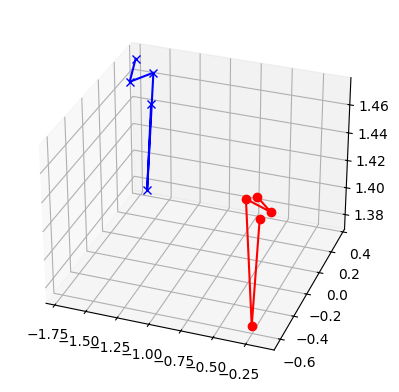

[[-0.5886 -0.8075  0.0386 -1.038 ]
 [ 0.8083 -0.5887  0.0117  0.9184]
 [ 0.0133  0.0381  0.9992  0.0016]
 [ 0.      0.      0.      1.    ]]


In [34]:
o1p = np.array([
    [-1.5562, 0.2572, 1.4492],
    [-1.6330, 0.3083, 1.3808],
    [-1.5965, 0.3571, 1.4649],
    [-1.6991, 0.2063, 1.4663],
    [-1.7070, 0.2998, 1.4768],
])
o2p = np.array([
    [-0.2731, -0.4744, 1.4389],
    [-0.2718, -0.5672, 1.3712],
    [-0.3304, -0.5649, 1.4582],
    [-0.1481, -0.5588, 1.4520],
    [-0.2185, -0.6201, 1.4654],
])
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.plot(o1p[:, 0], o1p[:, 1], o1p[:, 2], "bx-")
ax.plot(o2p[:, 0], o2p[:, 1], o2p[:, 2], "ro-")
ax.grid(True)
ax.view_init(30, -70)
plt.show()
T = t42point_sets(o1p, o2p)
print(T)


Calculate a shortest distance between two lines defined by points p1 and p2 and directions d1 and d2

<img src="assets/fg_two_lines.png" alt="fg_two_lines" style="zoom:33%;" />



In [35]:
np.set_printoptions(precision=4, suppress=True)
p1 = np.array([0.25, 0, -0.3])
d1 = np.array([-0.5000, 0, -0.8660])
p2 = np.array([1.5, 0.3, -0.8])
d2 = np.array([-0.4890, 0.5000, 0.7148])
distance, closest_points = dist2lines(p1, d1, p2, d2)
print(distance)
print(closest_points)


0.971186640095681
[[ 0.54    0.      0.2022]
 [ 0.9935  0.8179 -0.0596]]


# Interpolation functions 

For interpolation in joint space we can use standard interpolation functions available in MATLAB, like `interp1`. Also for interpolation of 3D positions in Cartesian task space, we can use `interp1`. On the other hand, the interpolation of orientations is not so straightforward. In RBS Toolbox we use in most cases the linear spherical interpolation SLERP. Basic functions for SLERP interpolation are

| Function                                 | Description                                    |
| ---------------------------------------- | ---------------------------------------------- |
| `q=slerp(q1,q2,s)`, `q=qinterp(q1,q2,s)` | SLERP interpolation for quaternion inputs      |
| `R=rinterp(R1,R2,s)`                     | SLERP interpolation for rotation matrix inputs |



In [36]:
q1 = r2q(rot_x(1, out="R"))
q2 = r2q(rot_z(2, out="R"))
s = np.linspace(0, 1, 6)
qq = slerp(q1, q2, s, short=True)
print(qq)


[[ 0.8776  0.4794 -0.     -0.    ]
 [ 0.8875  0.4132  0.      0.2042]
 [ 0.8563  0.3278  0.      0.399 ]
 [ 0.7856  0.2274  0.      0.5754]
 [ 0.6786  0.1164  0.      0.7252]
 [ 0.5403  0.      0.      0.8415]]


In [37]:
qq = slerp(q1, q2, s, short=False)
print(qq)


[[ 0.8776  0.4794 -0.     -0.    ]
 [ 0.7472  0.5427 -0.     -0.3836]
 [ 0.4912  0.5148 -0.     -0.7026]
 [ 0.1526  0.4003 -0.     -0.9036]
 [-0.2116  0.2185 -0.     -0.9526]
 [-0.5403 -0.     -0.     -0.8415]]




Interpolating between two spatial poses we combine linear interpolation for positions and SLERP interpolation for orientations. Functions for interpolation are 

| Function                   | Description                                                  |
| -------------------------- | ------------------------------------------------------------ |
| `x=xinterp(xa,xb,s)`       | Linear interpolation of  spatial pose (position+quaternion)  |
| `T=tinterp(Ta,Tb,s)`       | Linear interpolation for homogenous matrices                 |
| `x=xarcinterp(xa,xb,s)`    | Linear interpolation on arc for position and SLERP for orientation (position+quaternion) |
| `T=tarcinterp(Ta,Tb,pC,s)` | Linear interpolation on arc for position and SLERP for orientation (homogenous matrices) |



In [38]:

np.set_printoptions(precision=4, suppress=True)
x0 = t2x(rp2t(np.eye(3), [1, 0, 0.2], out="T"))
R = rot_y(np.pi / 2, out="R") @ rot_x(np.pi / 4, out="R")
x1 = t2x(rp2t(R, [0, 1, 4], out="T"))
s = np.linspace(0, 1, 6)
xx = xinterp(x0, x1, s)
print(xx)


[[ 1.      0.      0.2     1.     -0.     -0.     -0.    ]
 [ 0.8     0.2     0.96    0.9853  0.0611  0.1475 -0.0611]
 [ 0.6     0.4     1.72    0.9416  0.1204  0.2906 -0.1204]
 [ 0.4     0.6     2.48    0.8701  0.1761  0.4252 -0.1761]
 [ 0.2     0.8     3.24    0.7731  0.2267  0.5473 -0.2267]
 [ 0.      1.      4.      0.6533  0.2706  0.6533 -0.2706]]


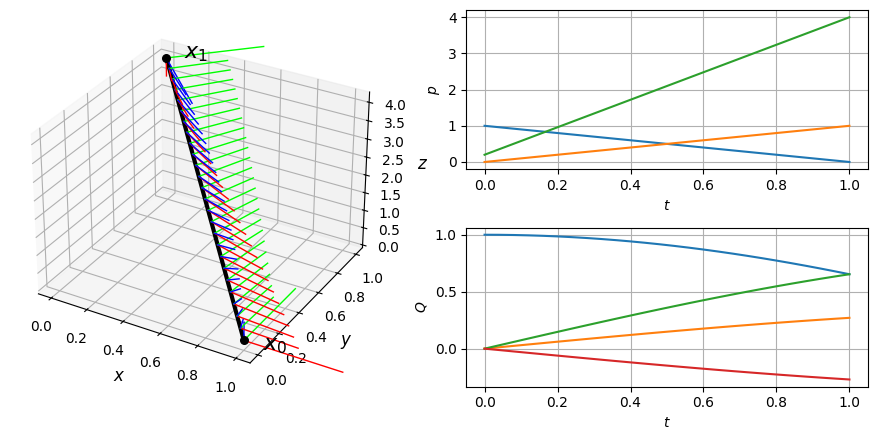

In [ ]:
x0 = t2x(rp2t(np.eye(3), [1, 0, 0.2], out="T"))
x1 = t2x(rp2t(rot_y(np.pi / 2, out="R") @ rot_x(np.pi / 4, out="R"), [0, 1, 4], out="T"))
s = np.linspace(0, 1, 6)
xx = xinterp(x0, x1, s)

s = np.linspace(0, 1, 26)
xx = xinterp(x0, x1, s)

fig = plt.figure(59)
fig.clf()
fig.set_size_inches(9, 4.5)
gs = fig.add_gridspec(2, 2)
ax3d = fig.add_subplot(gs[:, 0], projection="3d")
ax_pos = fig.add_subplot(gs[0, 1])
ax_ori = fig.add_subplot(gs[1, 1])

hx, _ = plotcpos_ori(s, x=xx, graph="3D", typ="Pos", ax=ax3d)
if hx and hx[0]:
    hx[0][0].set_linewidth(3)
    hx[0][0].set_color("k")

p0 = x0[:3]
p1 = x1[:3]
plotucs(x0, UCS_length=0.5, UCS_linewidth=1, ax=ax3d)
plotucs(x1, UCS_length=0.5, UCS_linewidth=1, ax=ax3d)
for i in range(1, len(s) - 1):
    plotucs(xx[i, :], UCS_length=0.3, UCS_linewidth=1, ax=ax3d)
ax3d.scatter(p0[0], p0[1], p0[2], color="k", s=30)
ax3d.scatter(p1[0], p1[1], p1[2], color="k", s=30)
ax3d.text(p0[0] + 0.1, p0[1], p0[2] - 0.1, r"$x_0$", fontsize=16)
ax3d.text(p1[0] + 0.1, p1[1], p1[2] + 0.1, r"$x_1$", fontsize=16)

ax_pos.plot(s, xx[:, 0:3])
ax_pos.set_ylabel(r"$p$")
ax_pos.set_xlabel(r"$t$")
ax_pos.grid(True)

ax_ori.plot(s, xx[:, 3:])
ax_ori.set_ylabel(r"$Q$")
ax_ori.set_xlabel(r"$t$")
ax_ori.grid(True)

fig.tight_layout()




![](README.assets/xinterp_1.png)

We can interpolate positions also on an arc



In [40]:
x0 = np.array([1, 0, 2, 1, 0, 0, 0])
R = rot_y(np.pi / 2, out="R") @ rot_x(np.pi / 4, out="R")
x1 = np.hstack(([0, 1, 4], r2q(R)))
pC = np.array([1, 1, 3])
s = np.linspace(0, 1, 6)
xx = xarcinterp(x0, x1, pC, s)
print(xx)


[[ 1.      0.      2.      1.      0.      0.      0.    ]
 [ 0.5303 -0.1484  2.3213  0.9853  0.0611  0.1475 -0.0611]
 [ 0.1419 -0.0982  2.7599  0.9416  0.1204  0.2906 -0.1204]
 [-0.0982  0.1419  3.2401  0.8701  0.1761  0.4252 -0.1761]
 [-0.1484  0.5303  3.6787  0.7731  0.2267  0.5473 -0.2267]
 [-0.      1.      4.      0.6533  0.2706  0.6533 -0.2706]]


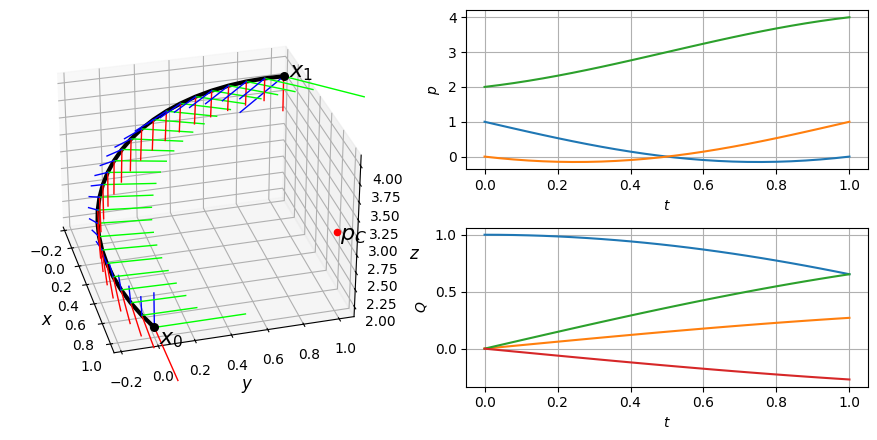

In [41]:
x0 = np.array([1, 0, 2, 1, 0, 0, 0])
R = rot_y(np.pi / 2, out="R") @ rot_x(np.pi / 4, out="R")
x1 = np.hstack(([0, 1, 4], r2q(R)))
pC = np.array([1, 1, 3])
s = np.linspace(0, 1, 26)
xx = xarcinterp(x0, x1, pC, s)

fig = plt.figure(59)
fig.clf()
fig.set_size_inches(9, 4.5)
gs = fig.add_gridspec(2, 2)
ax3d = fig.add_subplot(gs[:, 0], projection="3d")
ax_pos = fig.add_subplot(gs[0, 1])
ax_ori = fig.add_subplot(gs[1, 1])

hx, _ = plotcpos_ori(s, x=xx, graph="3D", typ="Pos", ax=ax3d)
if hx and hx[0]:
    hx[0][0].set_linewidth(3)
    hx[0][0].set_color("k")

p0 = x0[:3]
p1 = x1[:3]
plotucs(x0, UCS_length=0.5, UCS_linewidth=1, ax=ax3d)
plotucs(x1, UCS_length=0.5, UCS_linewidth=1, ax=ax3d)
for i in range(1, len(s) - 1):
    plotucs(xx[i, :], UCS_length=0.3, UCS_linewidth=1, ax=ax3d)
ax3d.scatter(p0[0], p0[1], p0[2], color="k", s=30)
ax3d.scatter(p1[0], p1[1], p1[2], color="k", s=30)
ax3d.scatter(pC[0], pC[1], pC[2], color="r", s=20)
ax3d.text(p0[0] + 0.1, p0[1], p0[2] - 0.1, r"$x_0$", fontsize=16)
ax3d.text(p1[0] + 0.1, p1[1], p1[2] + 0.1, r"$x_1$", fontsize=16)
ax3d.text(pC[0] + 0.05, pC[1], pC[2] - 0.05, r"$p_C$", fontsize=16)
ax3d.view_init(30, -15)

ax_pos.plot(s, xx[:, 0:3])
ax_pos.set_ylabel(r"$p$")
ax_pos.set_xlabel(r"$t$")
ax_pos.grid(True)

ax_ori.plot(s, xx[:, 3:])
ax_ori.set_ylabel(r"$Q$")
ax_ori.set_xlabel(r"$t$")
ax_ori.grid(True)

fig.tight_layout()
